<h1 style="color:#000066; text-align:center; font-size:40px">120 Years of Olympics History</h1>

<div style="text-align:center;">
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5c/Olympic_rings_without_rims.svg/800px-Olympic_rings_without_rims.svg.png" width="600px">
</div>

<a id='section-0'></a>

<h2 style="color:mediumseagreen;">Table of Contents:</h2>
<ol>
    <li><a href="#section-1" style="color:#0000ff;">Importing Required Libraries</a></li>
    <li><a href="#section-2" style="color:#0000ff;">Data Loading</a></li>
    <li><a href="#section-3" style="color:#0000ff;">Exploratory Data Analysis</a></li>
    <ol>
        <li><a href="#section-3.1" style="color:#0000ff;">Top 10 Countries Participated in 120 years</a></li>
        <li><a href="#section-3.2" style="color:#0000ff;">Age Distribution of the Participants</a></li>
        <li><a href="#section-3.3" style="color:#0000ff;">Different Sports in Summer and Winter Olympics</a></li>
        <li><a href="#section-3.4" style="color:#0000ff;">Total Team, Regions/NOC, Events in Summer Oympics and Winter Olympics</a></li>
        <li><a href="#section-3.5" style="color:#0000ff;">Participation based on Gender</a></li>
        <li><a href="#section-3.6" style="color:#0000ff;">Distribution According to Sex in both Season</a></li>
        <li><a href="#section-3.7" style="color:#0000ff;">Medals for Top 20 Countries in Summer Olympics</a></li>
        <li><a href="#section-3.8" style="color:#0000ff;">Atheletes Participated in Summer Olympics</a></li>
        <li><a href="#section-3.9" style="color:#0000ff;">Total Number of Female Athletes in Summer Olympics</a></li>
        <li><a href="#section-3.10" style="color:#0000ff;">Analysis of Gold Medalist</a></li>
        <li><a href="#section-3.11" style="color:#0000ff;">Analysis of Rio Olympics</a></li>
        <li><a href="#section-3.12" style="color:#0000ff;">Distribution of Height and Weight of Male and Female Athelete over Time in both Seasons</a></li>
    </ol>
    <li><a href="#section-4" style="color:#0000ff;">Data Cleaning</a></li>
    <li><a href="#section-5" style="color:#0000ff;">Feature Engineering</a></li>
    <li><a href="#section-6" style="color:#0000ff;">Model Building</a></li>
    <li><a href="#section-7" style="color:#0000ff;">Thank You</a></li>
</ol>

<a id='section-1'></a>
<h1 style="color:#347347;">Importing Required Libraries</h1>

In [2]:
# Data Processing
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns 

# Model Building
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

<a id='section-2'></a>
<h1 style="color:#347347;">Data Loading</h1>

In [4]:
athletes_df = pd.read_csv('athlete_events.csv')

regions_df = pd.read_csv('noc_regions.csv')

In [3]:
# lets check the glimpse of first five rows of athletes dataframe
athletes_df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [4]:
# lets check the glimpse of first five rows of regions dataframe
regions_df.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


In [5]:
# shape of dataframe
print('Shape of Athlete DF {}\n'.format(athletes_df.shape))
print('Shape of Regions DF {}'.format(regions_df.shape))

Shape of Athlete DF (271116, 15)

Shape of Regions DF (230, 3)


In [51]:
# lets merge athlete events and region based on NOC
df_merged = athletes_df.merge(regions_df,on='NOC',how='left')

In [7]:
## Getting an overview of our data
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 271116 entries, 0 to 271115
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
 15  region  270746 non-null  object 
 16  notes   5039 non-null    object 
dtypes: float64(3), int64(2), object(12)
memory usage: 37.2+ MB


In [8]:
# summary statistics
df_merged.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [9]:
# lets check for missing values
df_merged.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
region       370
notes     266077
dtype: int64

<p style="color:#000066; font-size:20px;">From the above code,its clearly shows that "Age", "Height", "Weight" and "Medal" are the only columns that have missing values. But, missing values in "Medal" column doesn't mean the actual missing values. It might be mostly due to the players who didn't win any medal for the particular even. Therefore, while imputing the values its recommended to impute values only to "Age", "Height" and "Weight" columns in the dataset.</p>

<h5><a href="#section-0" style="color:#ff6600;">Back To Content Table</a></h5>

<a id='section-3'></a>
<h1 style="color:#347347;">Exploratory Data Analysis</h1>

In [32]:
df_merged['Height'] = df_merged.groupby(['Sport','Sex'])['Height'].transform(lambda x: x.fillna(x.median()))
df_merged['Weight'] = df_merged.groupby(['Sport','Sex'])['Weight'].transform(lambda x: x.fillna(x.median()))
df_merged['Age'] = df_merged.groupby(['Sport','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

In [33]:
#to fill height weight and age where 0 data available for particular sport+sex combo
df_merged[['Age', 'Height', 'Weight']] = df_merged[['Age', 'Height', 'Weight']].fillna(df_merged[['Age', 'Height', 'Weight']].median())

In [34]:
# Handle Medals
df_merged['Medal'].fillna('No Medal', inplace=True)

<a id='section-3.1'></a>
<h3 style="color:#F20707;">Top 10 Countries Participated in 120 years</h3>

In [10]:
# Top 10 countries participated
top_10_countries = df_merged['Team'].value_counts().nlargest(10)
top_10_countries

United States    17847
France           11988
Great Britain    11404
Italy            10260
Germany           9326
Canada            9279
Japan             8289
Sweden            8052
Australia         7513
Hungary           6547
Name: Team, dtype: int64

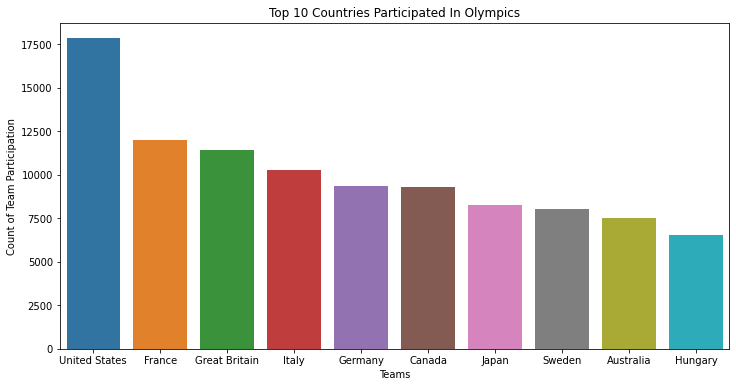

In [11]:
# plot for top 10 countries
plt.figure(figsize=(12,6))
sns.barplot(x = top_10_countries.index,y = top_10_countries)
plt.xlabel('Teams')
plt.ylabel('Count of Team Participation')
plt.title('Top 10 Countries Participated In Olympics')
plt.show()

<a id='section-3.2'></a>
<h3 style="color:#F20707;">Age Distribution of the Participants</h3>

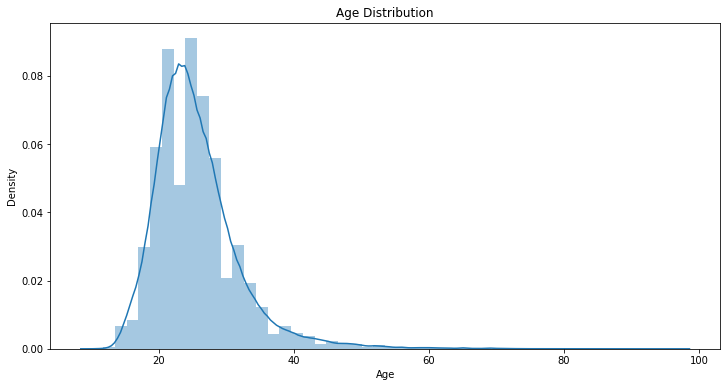

In [12]:
# Age distribution of the participants
plt.figure(figsize=(12,6))
sns.distplot(df_merged.Age)
plt.xlabel('Age')
plt.title('Age Distribution')
plt.show()

<p style="color:#000066; font-size:20px;">We have most number of athletes who have age between 20 to 40 years.</p>

<p style="color:#000066; font-size:60px;">We have most number of athletes who have age between 20 to 40 years.</p>

<a id='section-3.3'></a>
<h3 style="color:#F20707;">Different Sports in Summer and Winter Olympics</h3>

In [13]:
# winter olympic sports
winter_sports = df_merged[df_merged['Season'] == 'Winter'].Sport.unique()
winter_sports

array(['Speed Skating', 'Cross Country Skiing', 'Ice Hockey', 'Biathlon',
       'Alpine Skiing', 'Luge', 'Bobsleigh', 'Figure Skating',
       'Nordic Combined', 'Freestyle Skiing', 'Ski Jumping', 'Curling',
       'Snowboarding', 'Short Track Speed Skating', 'Skeleton',
       'Military Ski Patrol', 'Alpinism'], dtype=object)

In [14]:
# summer olympic sports
summer_sports = df_merged[df_merged['Season'] == 'Summer'].Sport.unique()
summer_sports

array(['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
       'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
       'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
       'Water Polo', 'Hockey', 'Rowing', 'Fencing', 'Equestrianism',
       'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
       'Tennis', 'Modern Pentathlon', 'Golf', 'Softball', 'Archery',
       'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
       'Rhythmic Gymnastics', 'Rugby Sevens', 'Trampolining',
       'Beach Volleyball', 'Triathlon', 'Rugby', 'Lacrosse', 'Polo',
       'Cricket', 'Ice Hockey', 'Racquets', 'Motorboating', 'Croquet',
       'Figure Skating', 'Jeu De Paume', 'Roque', 'Basque Pelota',
       'Alpinism', 'Aeronautics'], dtype=object)

<h5><a href="#section-0" style="color:#ff6600;">Back To Content Table</a></h5>

<a id='section-3.4'></a>
<h3 style="color:#F20707;">Total Team, Regions/NOC, Events in Summer Oympics and Winter Olympics</h3>

In [15]:
total_count = df_merged.groupby("Season")[["Team", "NOC", "Event", "City", "Sport"]].nunique().reset_index()
total_count

,Season,Team,NOC,Event,City,Sport
0,Summer,1157,230,651,23,52
1,Winter,221,119,119,19,17


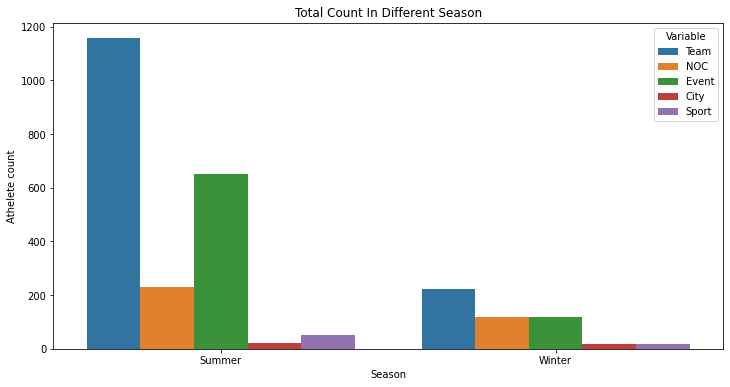

In [16]:
tidy = total_count.melt(id_vars='Season').rename(columns=str.title)

plt.subplots(figsize=(12, 6))
sns.barplot(x='Season', y='Value', hue='Variable', data=tidy)
plt.title('Total Count In Different Season')
plt.ylabel("Athelete count")
plt.show()

<a id='section-3.5'></a>
<h3 style="color:#F20707;">Participation based on Gender</h3>

In [17]:
# male and female participants
gender_counts = df_merged.Sex.value_counts()
gender_counts

M    196594
F     74522
Name: Sex, dtype: int64

<p style="color:#000066; font-size:20px;">Since Inception of olympics, we have more number of male participants than female participants.</p>

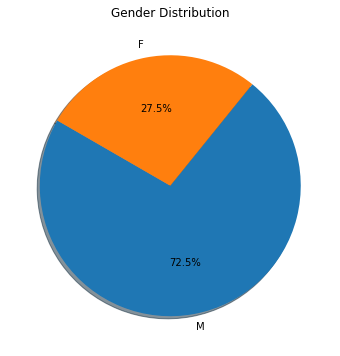

In [18]:
# pie chart for male and female participants
plt.figure(figsize=(12,6))
plt.pie(gender_counts,labels = gender_counts.index, autopct = '%1.1f%%',startangle=150,shadow=True )
plt.title('Gender Distribution')
plt.show()

<a id='section-3.6'></a>
<h3 style="color:#F20707;">Distribution According to Sex in both Season</h3>

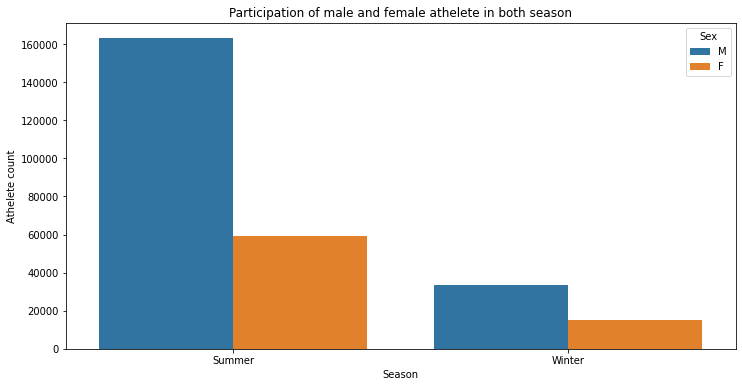

In [19]:
plt.figure(figsize=(12,6))
sns.countplot(x="Season", hue="Sex", data=df_merged)
plt.title('Participation of male and female athelete in both season')
plt.ylabel("Athelete count")
plt.show()

<a id='section-3.7'></a>
<h3 style="color:#F20707;">Medals for Top 20 Countries in Summer Olympics</h3>

In [35]:
# Total medals
df_merged.Medal.value_counts()  #this

Medal
No Medal    231333
Gold         13372
Bronze       13295
Silver       13116
Name: count, dtype: int64

In [39]:
#FEATURE ENGINEERING (One-Hot Encoding Medals)
# ---------------------------------------------------------
# Process: One-Hot Encoding
# This turns the "Medal" text into 1s and 0s so we can count them
medal_dummies = pd.get_dummies(df_merged['Medal'],dtype=int)

# We only keep the win columns (Gold, Silver, Bronze)
medal_cols = ['Gold', 'Silver', 'Bronze']
for col in medal_cols:
    if col not in medal_dummies.columns:
        medal_dummies[col] = 0 # Safety check if a medal type is missing

df_combined = pd.concat([df_merged, medal_dummies[medal_cols]], axis=1)
df_combined 

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Gold,Silver,Bronze
0,1,A Dijiang,M,24.0,180.000000,80.000000,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No Medal,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.000000,60.000000,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,175.402195,70.446834,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,No Medal,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,182.480000,95.615385,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,1,0,0
4,5,Christine Jacoba Aaftink,F,21.0,185.000000,82.000000,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,No Medal,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.000000,89.000000,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,No Medal,Poland,NaN,0,0,0
271112,135570,Piotr ya,M,27.0,176.000000,59.000000,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",No Medal,Poland,NaN,0,0,0
271113,135570,Piotr ya,M,27.0,176.000000,59.000000,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",No Medal,Poland,NaN,0,0,0
271114,135571,Tomasz Ireneusz ya,M,30.0,185.000000,96.000000,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,No Medal,Poland,NaN,0,0,0


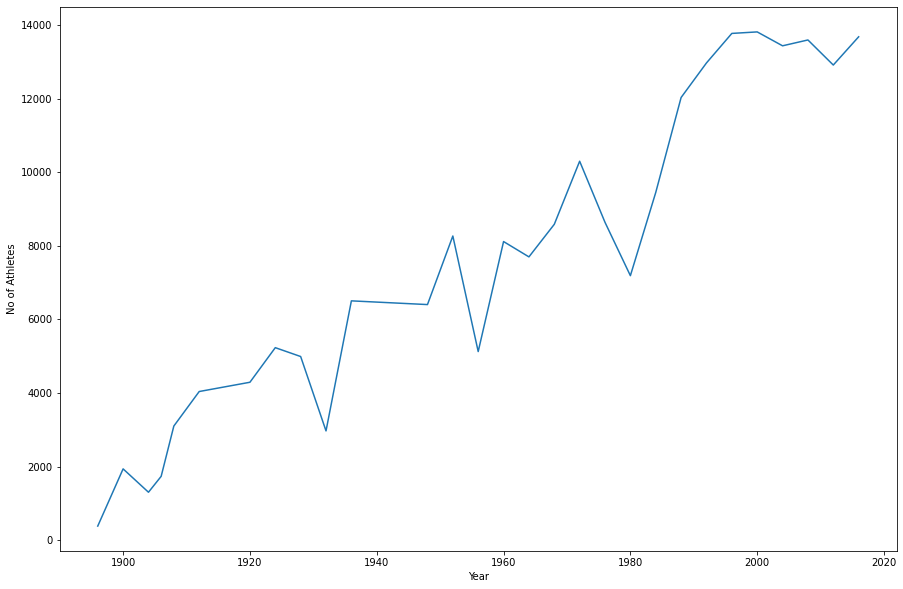

In [22]:
# Atheletes Participated in Summer Olympics
athletes_per_year = df_merged[df_merged['Season']=='Summer'].groupby('Year')['ID'].count().reset_index()

plt.figure(figsize=(15, 10))
sns.lineplot(data=athletes_per_year, x="Year", y="ID")
plt.xlabel('Year')
plt.ylabel('No of Athletes')
plt.show()

In [52]:
# total number of female athletes in summer olympics
female_participants = df_merged[(df_merged['Sex'] == 'F') & (df_merged['Season'] == 'Summer')][['Sex','Year']]
female_participants = female_participants.groupby('Year').count().reset_index()
female_participants.head()

,Year,Sex
0,1900,33
1,1904,16
2,1906,11
3,1908,47
4,1912,87


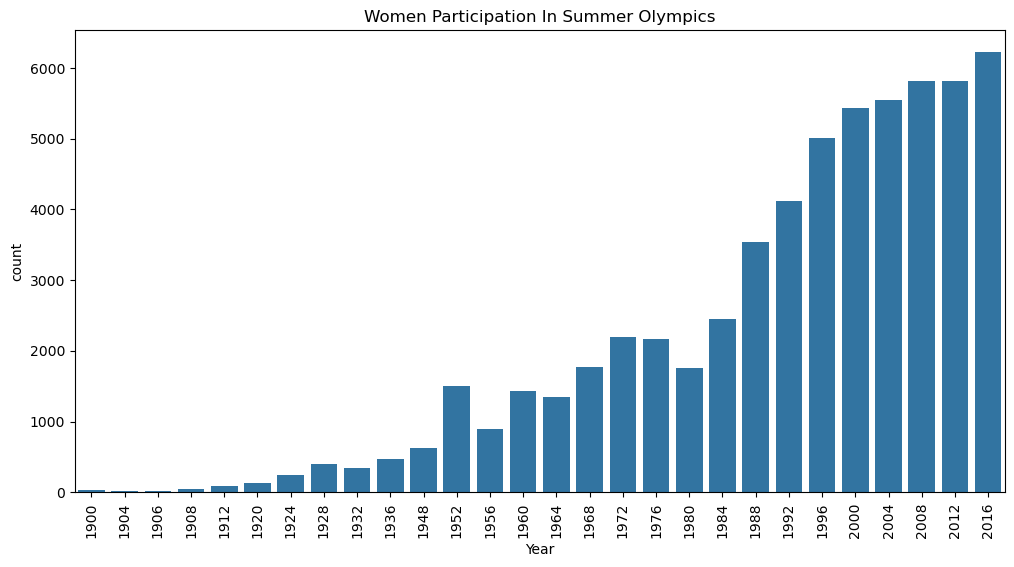

In [31]:
# female athletes in summer olympics
women_olympics = df_merged[(df_merged['Sex'] == 'F') & (df_merged['Season'] == 'Summer')]

# count plot for women participation
plt.figure(figsize=(12,6))
sns.countplot(x='Year',data=women_olympics)
plt.title('Women Participation In Summer Olympics')
plt.xticks(rotation=90)
plt.show()

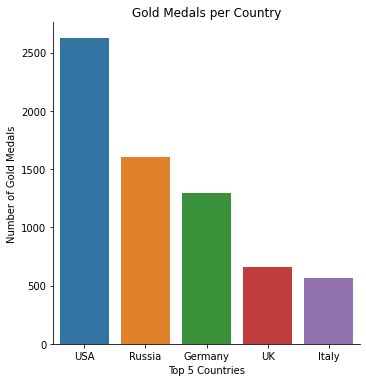

In [31]:
totalGoldMedals = goldMedals.region.value_counts().reset_index(name='Medal').head()


sns.catplot(x='index',y='Medal',data=totalGoldMedals,
           height=5,kind='bar')
plt.xlabel('Top 5 Countries')
plt.ylabel('Number of Gold Medals')
plt.title('Gold Medals per Country')
plt.show()

In [47]:
# lets look at the relationship between height and weight
df_merged = [(df_merged['Height'].notnull()) & (df_merged['Weight'].notnull())]

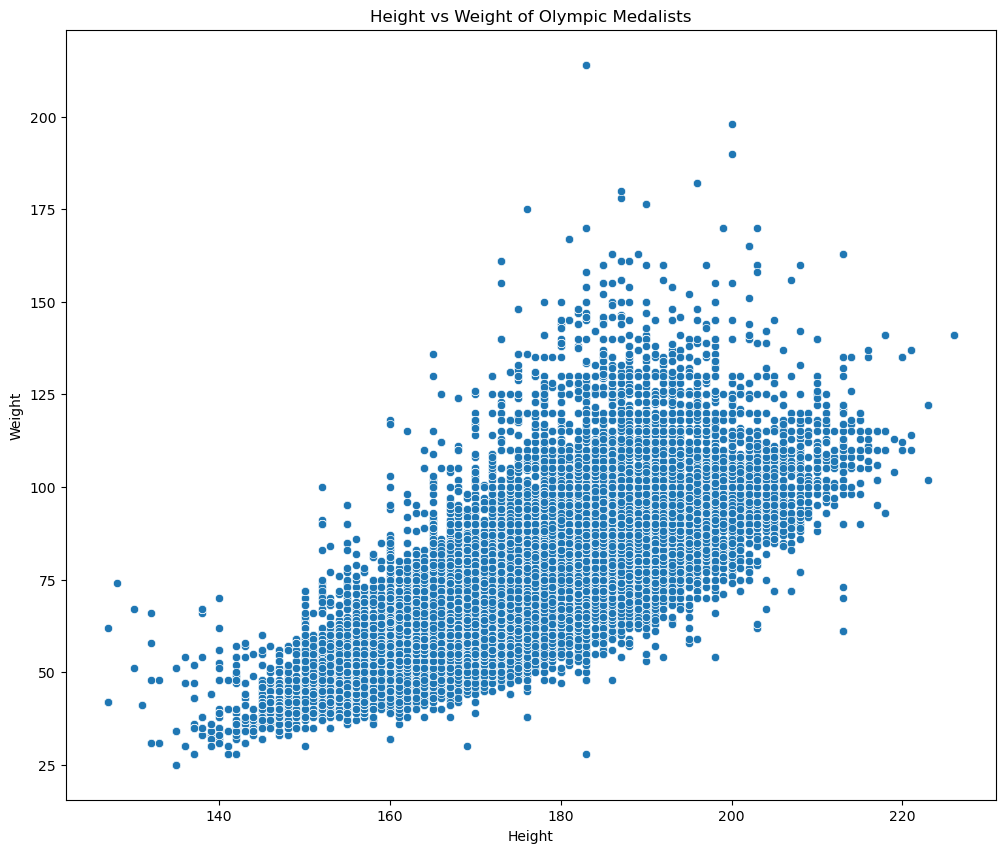

In [53]:
plt.figure(figsize=(12, 10))
sns.scatterplot(x="Height", y="Weight", data=df_merged)
plt.title('Height vs Weight of Olympic Medalists')
plt.show()

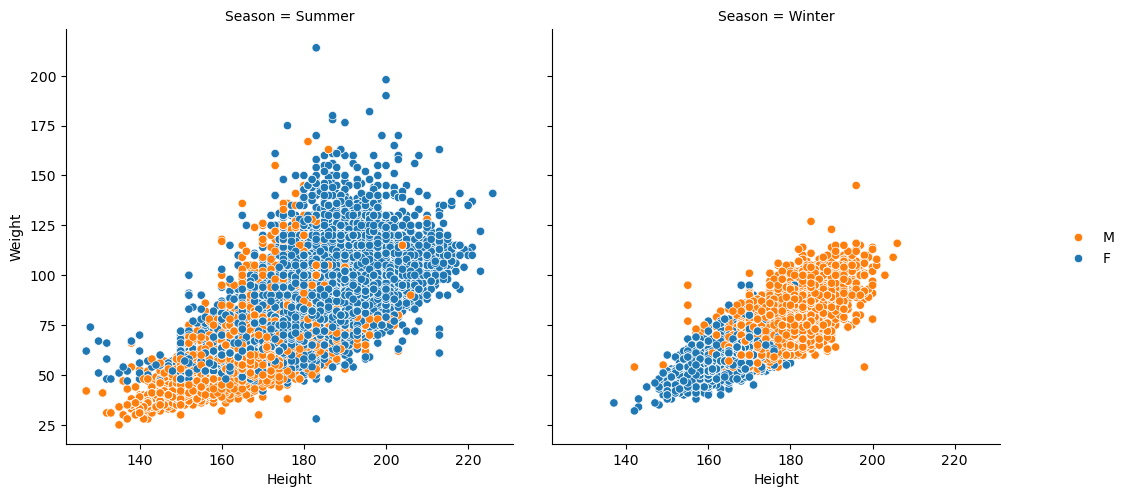

In [54]:
#Distribution of Height and Weight of Male and Female Athelete over Time in both Seasons
merged_df_cleaned = df_merged[(df_merged['Height'].notnull()) & (df_merged['Weight'].notnull())]

g = sns.FacetGrid(merged_df_cleaned,col="Season")
g.map(sns.scatterplot, "Height", "Weight","Sex")
g.add_legend()
fig = plt.gcf()
fig.set_size_inches(12, 6)
plt.show()

<a id='section-4'></a>
<h1 style="color:#347347;">Data Cleaning</h1>

In [55]:
df_merged.shape

(271116, 17)

In [63]:
df_merged

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,Poland,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,Poland,NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,Poland,NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,Poland,NaN


In [70]:
#This creates the Gold, Silver, and Bronze columns with 1s and 0s
medal_dummies = pd.get_dummies(df_merged['Medal'], dtype=int)

# Add only the winning columns to our main dataframe
for col in ['Gold', 'Silver', 'Bronze']:
    if col in medal_dummies.columns:
        df_merged[col] = medal_dummies[col]
    else:
        df_merged[col] = 0 # In case a medal type is missing in the data

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_absolute_error, classification_report
import warnings

In [75]:
# 3. ONE-HOT ENCODING (Medals to 1s and 0s)
# Using dtype=int ensures we get 1/0 instead of True/False
medal_dummies = pd.get_dummies(df_merged['Medal'], dtype=int)
for col in ['Gold', 'Silver', 'Bronze']:
    df_merged[col] = medal_dummies[col] if col in medal_dummies.columns else 0

In [76]:
# ---------------------------------------------------------
# 4. DATA AGGREGATION (Fixed Binning Logic)
# ---------------------------------------------------------
country_df = df_merged.groupby(['region', 'Year']).agg({
    'ID': 'count',
    'Age': 'mean', 
    'Height': 'mean', 
    'Weight': 'mean',
    'Gold': 'sum',
    'Silver': 'sum',
    'Bronze': 'sum'
}).reset_index().dropna()

country_df['Total_Medals'] = country_df['Gold'] + country_df['Silver'] + country_df['Bronze']

# FIX: Using pd.cut with manual bins to avoid "Bin edges must be unique" error
# We define boundaries: -1 to 2 (Low), 2 to 20 (Medium), 20 to Max (High)
country_df['Performance_Tier'] = pd.cut(country_df['Total_Medals'], 
                                         bins=[-1, 2, 20, country_df['Total_Medals'].max()], 
                                         labels=['Low', 'Medium', 'High'])

In [77]:
# ---------------------------------------------------------
# 5. FEATURE SELECTION
# ---------------------------------------------------------
X_pool = country_df[['ID', 'Age', 'Height', 'Weight']]
y_reg = country_df['Total_Medals']

sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=2, direction='forward')
sfs.fit(X_pool, y_reg)
X_selected = X_pool[X_pool.columns[sfs.get_support()]]

print(f"Algorithm selected features: {X_pool.columns[sfs.get_support()].tolist()}")

Algorithm selected features: ['ID', 'Weight']


In [78]:
# ---------------------------------------------------------
# 6. REGRESSION MODELS
# ---------------------------------------------------------
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_selected, y_reg, test_size=0.2, random_state=42)

reg1 = LinearRegression().fit(Xr_train, yr_train)
reg2 = Lasso(alpha=0.1).fit(Xr_train, yr_train)
reg3 = SVR(kernel='rbf').fit(Xr_train, yr_train)

print("\n--- REGRESSION MAE ---")
print(f"Linear Regression: {mean_absolute_error(yr_test, reg1.predict(Xr_test)):.2f}")
print(f"Lasso Regression:  {mean_absolute_error(yr_test, reg2.predict(Xr_test)):.2f}")
print(f"SVR:               {mean_absolute_error(yr_test, reg3.predict(Xr_test)):.2f}")


--- REGRESSION MAE ---
Linear Regression: 9.85
Lasso Regression:  9.85
SVR:               8.47


In [79]:
# ---------------------------------------------------------
# 7. CLASSIFICATION MODELS (With PCA)
# ---------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pool)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_pca, country_df['Performance_Tier'], test_size=0.2, random_state=42)

clf1 = LogisticRegression().fit(Xc_train, yc_train)
clf2 = KNeighborsClassifier(n_neighbors=5).fit(Xc_train, yc_train)
clf3 = SVC(kernel='linear').fit(Xc_train, yc_train)

print("\n--- CLASSIFICATION REPORT (SVM) ---")
print(classification_report(yc_test, clf3.predict(Xc_test)))


--- CLASSIFICATION REPORT (SVM) ---
              precision    recall  f1-score   support

        High       0.78      0.78      0.78        91
         Low       0.84      0.97      0.90       407
      Medium       0.54      0.25      0.34       112

    accuracy                           0.81       610
   macro avg       0.72      0.67      0.67       610
weighted avg       0.78      0.81      0.78       610



<h5><a href="#section-0" style="color:#ff6600;">Back To Content Table</a></h5>

In [57]:
# Random Forest classifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [58]:
# Predict
y_pred = rf.predict(X_test)

In [59]:
print("Classification Report:\n\n", classification_report(y_test, y_pred))

Classification Report:

               precision    recall  f1-score   support

           0       0.94      0.99      0.97     46256
           1       0.93      0.64      0.76      7968

    accuracy                           0.94     54224
   macro avg       0.94      0.81      0.86     54224
weighted avg       0.94      0.94      0.93     54224

